# Step 7: Types of Bioactivity Data in Drug Discovery
Explanation Script: "In drug discovery, bioactivity data comes in two main forms: classification (active vs inactive) and regression (continuous values like IC50). IC50 is the concentration needed to inhibit 50% of the target's activity. Lower IC50 means more potent. Scientists often convert IC50 to pIC50 (-log10 IC50) because it creates a normal distribution better for modeling."


IC50 (nM)  pIC50  Classification
-----------------------------------
     2      8.70    ACTIVE
     7      8.15    ACTIVE
     4      8.40    ACTIVE
    12      7.92    ACTIVE
    45      7.35    ACTIVE
   110      6.96    ACTIVE
   350      6.46    ACTIVE
   800      6.10    ACTIVE
  1400      5.85    inactive
  2000      5.70    inactive
  5500      5.26    inactive
 15000      4.82    inactive
    25      7.60    ACTIVE
    57      7.24    ACTIVE
   179      6.75    ACTIVE
   320      6.49    ACTIVE
   820      6.09    ACTIVE
  2100      5.68    inactive
  6500      5.19    inactive
  9900      5.00    inactive
 30000      4.52    inactive
 45000      4.35    inactive
 50000      4.30    inactive


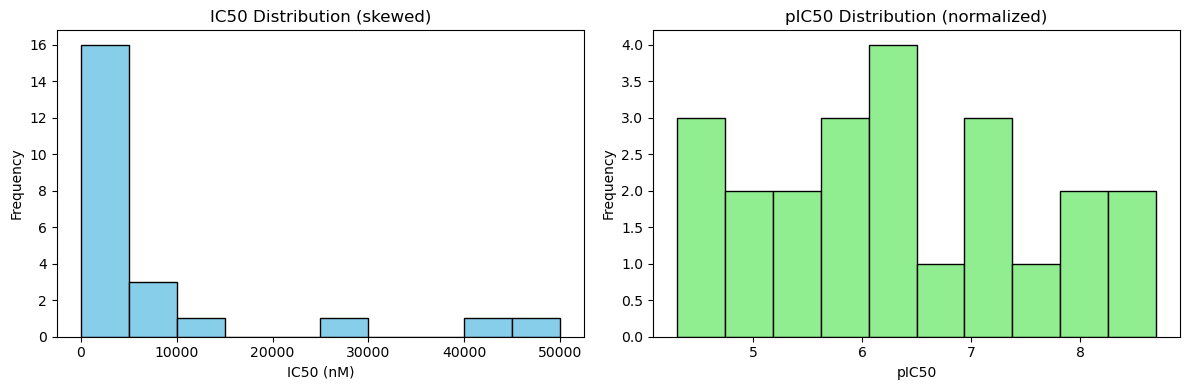


pIC50 transforms skewed data into normal distribution
This makes it better for machine learning models


In [1]:
import numpy as np
import matplotlib.pyplot as plt


# Simulated IC50 values for 20 compounds (in nanomolar)
ic50_values = [2,7,4, 12, 45, 110, 350, 800, 1400, 2000, 5500, 15000,
               25, 57, 179, 320, 820, 2100, 6500, 9900, 30000, 45000, 50000]


# Convert to pIC50 (convert nM to M first: divide by 1e9)
pic50_values = [-np.log10(ic50/1e9) for ic50 in ic50_values]


print("IC50 (nM)  pIC50  Classification")
print("-" * 35)


for i, (ic50, pic50) in enumerate(zip(ic50_values, pic50_values)):
    # Classification: Active if IC50 < 1000 nM (1 μM)
    active = "ACTIVE" if ic50 < 1000 else "inactive"
    print(f"{ic50:6.0f}     {pic50:5.2f}    {active}")


# Visualize distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))


ax1.hist(ic50_values, bins=10, color='skyblue', edgecolor='black')
ax1.set_xlabel('IC50 (nM)')
ax1.set_ylabel('Frequency')
ax1.set_title('IC50 Distribution (skewed)')


ax2.hist(pic50_values, bins=10, color='lightgreen', edgecolor='black')
ax2.set_xlabel('pIC50')
ax2.set_ylabel('Frequency')
ax2.set_title('pIC50 Distribution (normalized)')


plt.tight_layout()
plt.show()


print("\npIC50 transforms skewed data into normal distribution")
print("This makes it better for machine learning models")


### Explanation of Output:  
"The left histogram shows IC50 values heavily skewed toward lower concentrations, while the right histogram shows pIC50 values forming a normal distribution. This normalized data works better for machine learning models."